In [56]:
params <- list(
    i_counts_tab="results/ASVs_counts.tsv",
    i_norm_counts_tab="results/ASVs_counts_normalized.tsv",
    i_distances_matrix="results/ASVs_euclidean_distance.tsv",
    i_taxa_table="results/ASVs_taxa.tsv",
    i_reads_loss="results/reads_loss_summary.tsv",
    all_meta="resources/metadata/all_meta.csv"
)

In [57]:
library(DESeq2)
library(vegan)
library(dplyr)
library(dada2)
library(phyloseq)

In [58]:
counts_tab <- read.csv(params$i_counts_tab,sep = "\t", row.names='X')

samples_info <- read.csv(params$all_meta, row.names='Run')[colnames(counts_tab), ]
euc_dist_all <- as.dist(as.matrix(read.csv(
    params$i_distances_matrix, 
    sep='\t', 
    header=T,
    row.names=1
)))
taxa_table <- as.matrix(read.csv(params$i_taxa_table, sep = "\t", row.names=1))

samples_info_phy <- sample_data(samples_info)
taxa_table_phy <- tax_table(taxa_table)

phy <- phyloseq(otu_table(counts_tab, taxa_are_rows = T), samples_info_phy, taxa_table_phy)

meta <- data.frame(sample_data(phy))
predictors <- c('depr_or_control', 'batch', 'd_sex', 'd_age_hc')
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")

In [59]:
unique(meta$bd_phq9_any_dep)

[1] "PHQ-9>=5" "PHQ-9<5"

In [60]:
deseq_counts <- phyloseq_to_deseq2(phy, ~ bd_phq9_any_dep + batch + d_sex + d_age_hc_grp_10yr)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [61]:
deseq_counts <- estimateSizeFactors(deseq_counts, type = "poscounts")

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [62]:
dds <- DESeq(deseq_counts, test="Wald", fitType="parametric")

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

-- replacing outliers and refitting for 1116 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing

  Note: levels of factor

In [63]:
resultsNames(dds)

[1] "Intercept"                           "bd_phq9_any_dep_PHQ.9..5_vs_PHQ.9.5"
[3] "batch_B2_vs_B1"                      "d_sex_male_vs_female"               
[5] "d_age_hc_grp_10yr_45.54_vs_35.44"    "d_age_hc_grp_10yr_55.64_vs_35.44"   
[7] "d_age_hc_grp_10yr_65._vs_35.44"

In [64]:
res <- results(dds, name='bd_phq9_any_dep_PHQ.9..5_vs_PHQ.9.5')
summary(res)
as.data.frame(head(res))


out of 5215 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 14, 0.27%
LFC < 0 (down)     : 175, 3.4%
outliers [1]       : 519, 10%
low counts [2]     : 1772, 34%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ASV_1,633.6721,-0.6040112,0.3720775,-1.6233477,0.104515106,0.75640629
ASV_2,505.8231,-0.3449218,0.5076924,-0.6793913,0.496889944,0.99996200
ASV_3,351.8151,0.1075774,0.4109277,0.2617916,0.793482090,0.99996200
ASV_4,294.4243,-1.8043217,0.6209949,-2.9055337,0.003666274,0.06657417
ASV_5,317.3392,-0.5462167,0.6037681,-0.9046797,0.365635120,0.99996200
ASV_6,316.2567,0.2277295,0.3653018,0.6234011,0.533020955,0.99996200


In [65]:
res = results(dds, cooksCutoff = FALSE)
alpha = 0.01
sigtab = res[which(res$padj < alpha), ]
sigtab = cbind(as(sigtab, "data.frame"), as(tax_table(phy)[rownames(sigtab), ], "matrix"))
head(sigtab)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,domain,phylum,class,order,family,genus,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
ASV_86,47.61958,24.354203,3.580639,6.801636,1.034378e-11,2.990388e-09,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Rikenellaceae RC9 gut group,NA
ASV_123,17.04856,21.082357,4.561165,4.622143,3.797959e-06,1.546465e-04,Bacteria,Bacillota,Clostridia,NA,NA,NA,NA
ASV_127,48.21493,7.280219,2.096726,3.472184,5.162425e-04,9.045194e-03,Bacteria,Verrucomicrobiota,Verrucomicrobiia,Verrucomicrobiales,Akkermansiaceae,Akkermansia,NA
ASV_177,22.08542,22.475173,1.922544,11.690329,1.428319e-31,4.129269e-28,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Segatella,NA
ASV_180,22.69716,10.902396,1.793813,6.077779,1.218588e-09,1.677590e-07,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,NA
ASV_206,24.59089,-16.576328,3.702554,-4.476998,7.569993e-06,2.735555e-04,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Prevotellaceae,Segatella,NA


In [66]:
library(DESeq2)
library(phyloseq)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(tibble)
library(tidyr)
library(RColorBrewer)

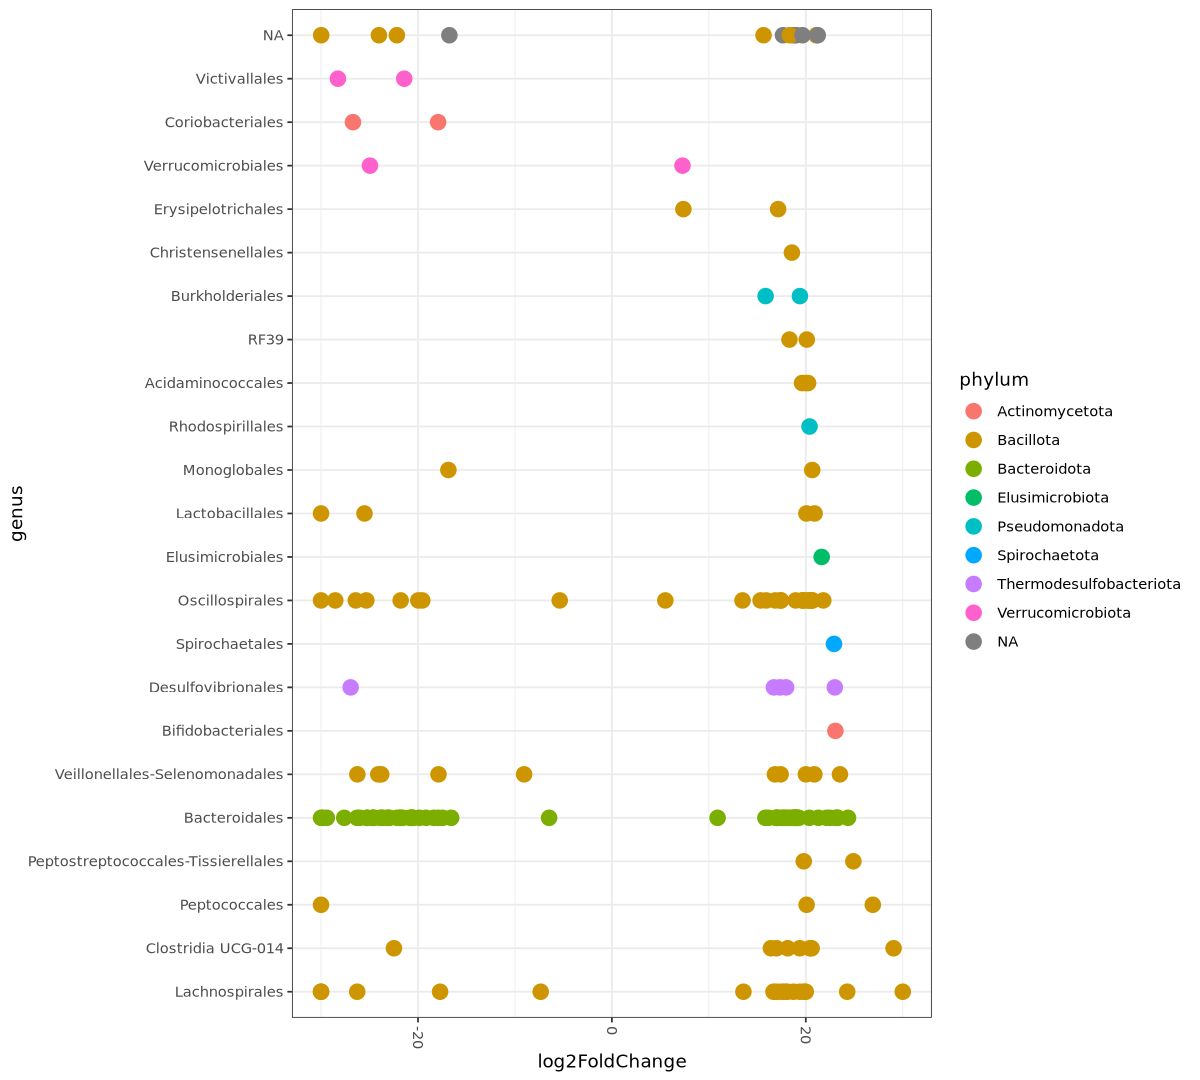

In [67]:
theme_set(theme_bw())
scale_fill_discrete <- function(palname = "Set1", ...) {
    scale_fill_brewer(palette = palname, ...)
}
color_cond <- sigtab$phylum
y_cond <- sigtab$order

x = tapply(sigtab$log2FoldChange, color_cond, function(x) max(x))
x = sort(x, TRUE)
sigtab$Phylum = factor(as.character(color_cond), levels=names(x))
# Genus order
x = tapply(sigtab$log2FoldChange, y_cond, function(x) max(x))
x = sort(x, TRUE)
sigtab$genus = factor(as.character(y_cond), levels=names(x))

ggplot(sigtab, aes(y=genus, x=log2FoldChange, color=phylum)) + 
  geom_point(size=4) + 
  theme(axis.text.x = element_text(angle = -90, hjust = 0, vjust=0.5))

options(repr.plot.width = 10, repr.plot.height = 9)

In [68]:
res_df <- as.data.frame(res) %>%
    rownames_to_column("ASV") %>%
    arrange(padj)

# Удаление NA
res_df <- res_df %>%
    filter(!is.na(padj))

# Категории значимости
res_df <- res_df %>%
    mutate(
        significance = case_when(
            padj < 0.05 & log2FoldChange > 1 ~ "Up",
            padj < 0.05 & log2FoldChange < -1 ~ "Down",
            TRUE ~ "NS"
        )
    )


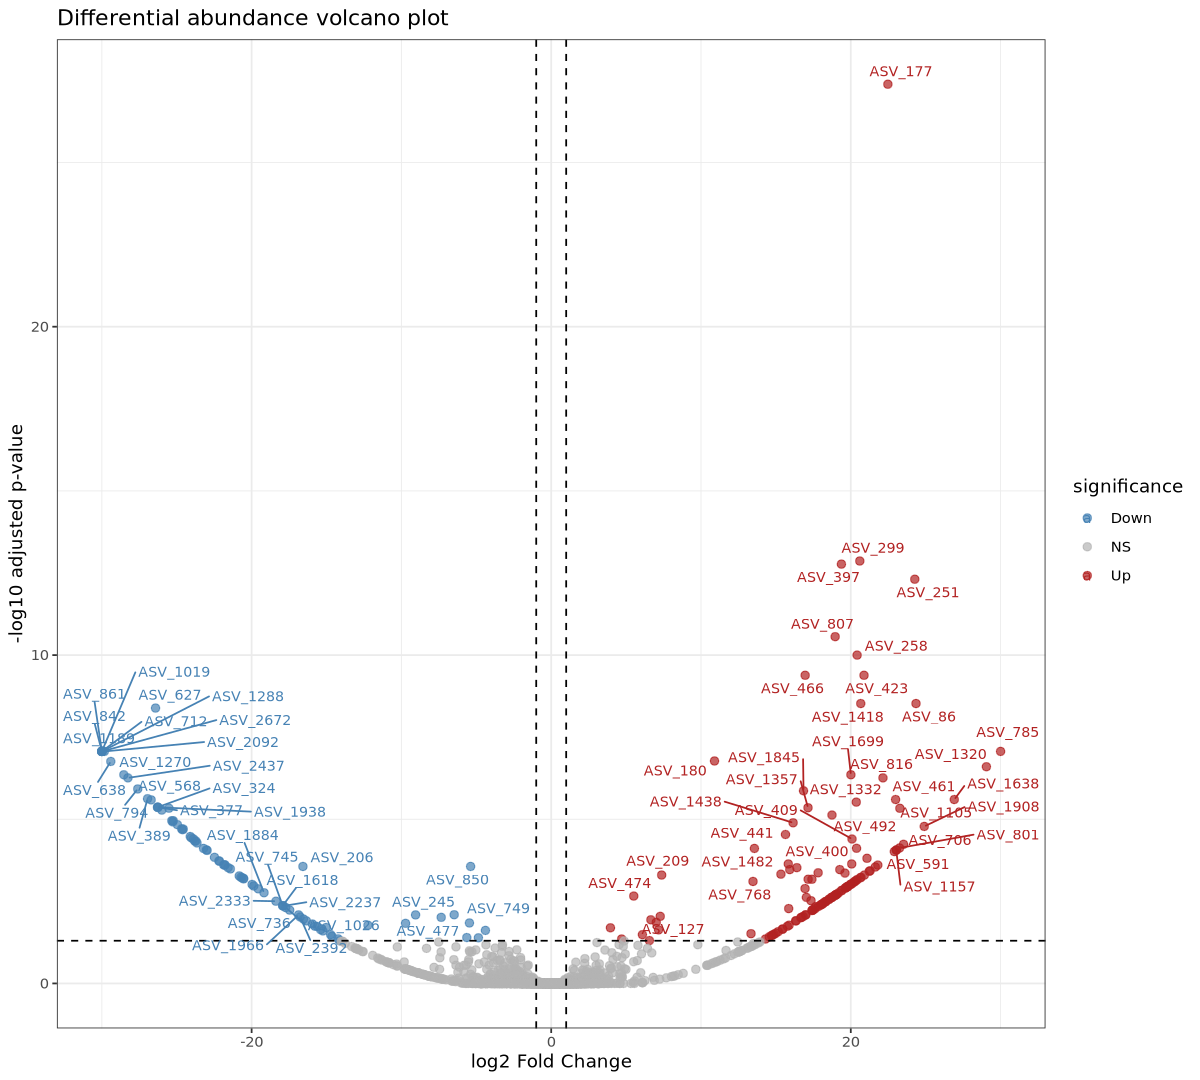

In [69]:
p_volcano <- ggplot(
    res_df,
    aes(
        x = log2FoldChange,
        y = -log10(padj),
        color = significance
    )
) +
    geom_point(alpha = 0.7, size = 2) +

    scale_color_manual(values = c(
        "Up" = "firebrick",
        "Down" = "steelblue",
        "NS" = "grey70"
    )) +

    geom_vline(xintercept = c(-1, 1),
               linetype = "dashed") +

    geom_hline(yintercept = -log10(0.05),
               linetype = "dashed") +

    geom_text_repel(
        data = subset(res_df, padj < 0.01),
        aes(label = ASV),
        size = 3,
        max.overlaps = 20
    ) +

    theme_bw() +

    labs(
        title = "Differential abundance volcano plot",
        x = "log2 Fold Change",
        y = "-log10 adjusted p-value"
    )

p_volcano

In [75]:
sig_asv <- res_df %>%
    filter(
        padj < 0.05,
        abs(log2FoldChange) > 1
    )

write.table(
    sig_asv,
    file = "results/significant_asv.tsv",
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

In [77]:
vsd <- varianceStabilizingTransformation(dds)
top_heatmap_asv <- sig_asv %>%
    arrange(padj) %>%
    slice_head(n = 30) %>%
    pull(ASV)

mat <- assay(vsd)[top_heatmap_asv, ]

# Z-score scaling
mat <- t(scale(t(mat)))

annotation_df <- data.frame(
    Depression = colData(dds)$bd_phq9_any_dep
)

rownames(annotation_df) <- colnames(mat)

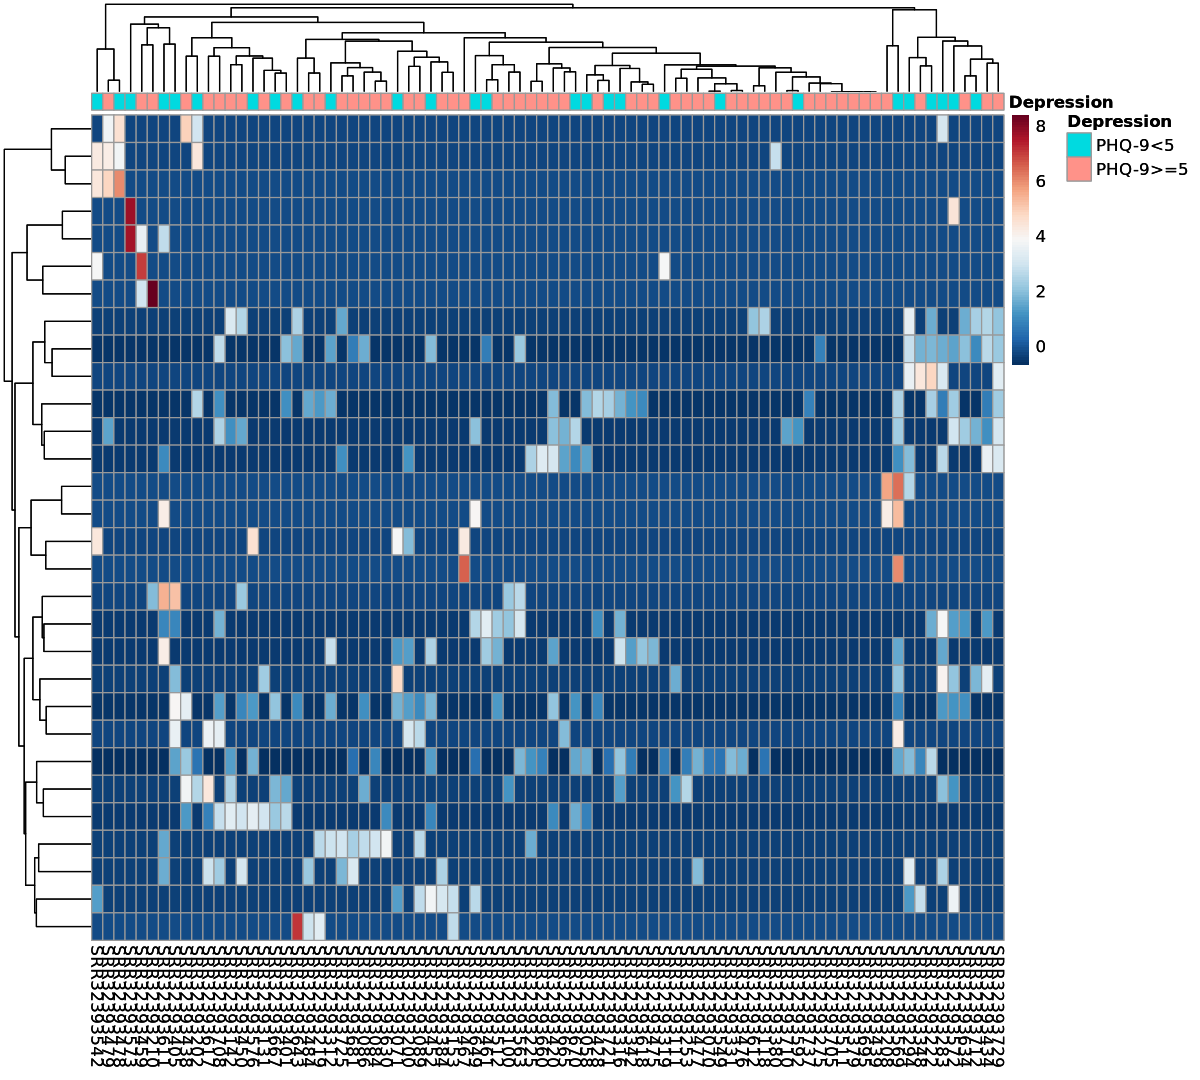

In [78]:
p <- pheatmap(
    mat,
    annotation_col = annotation_df,
    show_rownames = FALSE,
    clustering_method = "ward.D2",
    fontsize_col = 10,
    color = colorRampPalette(
        rev(brewer.pal(n = 11, name = "RdBu"))
    )(100),
    # filename = "results/top_asv_heatmap.png",
    width = 8,
    height = 10
)
show(p)

In [ ]:
tax_df <- as.data.frame(taxa)

sig_asv_tax <- sig_asv %>%
    left_join(
        tax_df %>%
            rownames_to_column("ASV"),
        by = "ASV"
    )